# 04 — KYC Compliance & AML EDA
## KYC Client Profiles + AML Transaction Signals
Two-dataset analysis: 2,000 client profiles merged with 50,000 AML transactions.
Focus: PEP detection, sanctions screening, FATF/OFAC flags, ownership opacity,
transaction structuring patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sqlite3
from datetime import datetime
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# ── Load KYC Datasets ───────────────────────────────────────────────
kyc1 = pd.read_csv('../../data/raw/kyc/kyc_part1.csv', parse_dates=['timestamp'])
kyc2 = pd.read_csv('../../data/raw/kyc/kyc_part2.csv')
print(f"Part1 (transactions): {kyc1.shape}")
print(f"Part2 (clients): {kyc2.shape}")
print(f"Unique clients in Part1: {kyc1['client_id'].nunique()}")
print(f"Unique clients in Part2: {kyc2['client_id'].nunique()}")

# Aggregate Part1 to client level
kyc1_agg = kyc1.groupby('client_id').agg(
    total_transactions=('transaction_id', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    ofac_matches=('ofac_match_flag', 'sum'),
    fatf_txn_flags=('fatf_country_flag', 'sum'),
    structuring_flags=('structuring_pattern_flag', 'sum'),
    rapid_movement_flags=('rapid_movement_flag', 'sum'),
    trade_mispricing_flags=('trade_mispricing_flag', 'sum'),
    unique_counterparty_countries=('counterparty_country', 'nunique'),
    client_country=('client_country', 'first')
).reset_index()

kyc_merged = kyc2.merge(kyc1_agg, on='client_id', how='left')
print(f"\nMerged shape: {kyc_merged.shape}")
print(f"Clients with transaction history: {kyc_merged['total_transactions'].notna().sum()}")

Part1 (transactions): (50000, 12)
Part2 (clients): (2000, 12)
Unique clients in Part1: 2000
Unique clients in Part2: 2000

Merged shape: (2000, 22)
Clients with transaction history: 2000


In [3]:
# ── SQL Analysis ────────────────────────────────────────────────────
con = sqlite3.connect(':memory:')
kyc_merged.to_sql('kyc', con, index=False, if_exists='replace')
kyc1.to_sql('kyc_txn', con, index=False, if_exists='replace')

# Q1: Risk flag summary
q1 = pd.read_sql_query("""
    SELECT COUNT(*) as total_clients,
           SUM(pep_flag) as pep_clients,
           ROUND(100.0*SUM(pep_flag)/COUNT(*),2) as pep_pct,
           SUM(sanctions_flag) as sanctioned_clients,
           ROUND(100.0*SUM(sanctions_flag)/COUNT(*),2) as sanctions_pct,
           SUM(fatf_country_flag) as fatf_clients,
           SUM(ofac_country_flag) as ofac_country_clients,
           SUM(sectoral_sanctions_flag) as sectoral_clients,
           ROUND(AVG(ownership_opacity_score),4) as avg_opacity
    FROM kyc
""", con)
print("Q1: Risk Flag Summary")
print(q1.to_string(index=False))
print()

# Q2: Risk by sector_risk level
q2 = pd.read_sql_query("""
    SELECT sector_risk, COUNT(*) as clients,
           SUM(pep_flag) as pep_count,
           SUM(sanctions_flag) as sanctions_count,
           ROUND(AVG(ownership_opacity_score),4) as avg_opacity
    FROM kyc GROUP BY sector_risk
    ORDER BY CASE sector_risk WHEN 'High' THEN 1 WHEN 'Medium' THEN 2 ELSE 3 END
""", con)
print("Q2: Risk by Sector Risk Level")
print(q2.to_string(index=False))
print()

# Q3: Top countries by combined risk
q3 = pd.read_sql_query("""
    SELECT country, COUNT(*) as clients,
           SUM(pep_flag) as pep_total,
           SUM(sanctions_flag) as sanctions_total,
           SUM(fatf_country_flag) as fatf_total,
           SUM(ofac_country_flag) as ofac_total,
           ROUND(AVG(ownership_opacity_score),4) as avg_opacity,
           (SUM(pep_flag)*3 + SUM(sanctions_flag)*3 + SUM(fatf_country_flag)*2 +
            SUM(ofac_country_flag)*2 + ROUND(AVG(ownership_opacity_score)*10)) as composite_risk_score
    FROM kyc GROUP BY country
    ORDER BY composite_risk_score DESC LIMIT 20
""", con)
print("Q3: Top 20 Countries by Composite Risk")
print(q3.to_string(index=False))
print()

# Q4: Client type breakdown
q4 = pd.read_sql_query("""
    SELECT client_type, COUNT(*) as count,
           SUM(pep_flag) as pep,
           SUM(sanctions_flag) as sanctions,
           ROUND(AVG(ownership_opacity_score),4) as avg_opacity
    FROM kyc GROUP BY client_type
""", con)
print("Q4: Client Type Breakdown")
print(q4.to_string(index=False))
print()

# Q5: Transaction-level AML flags
q5 = pd.read_sql_query("""
    SELECT ofac_match_flag, COUNT(*) as count,
           ROUND(AVG(amount),2) as avg_amount
    FROM kyc_txn GROUP BY ofac_match_flag
""", con)
print("Q5: OFAC Match Flag Distribution")
print(q5.to_string(index=False))
print()

# Q6: Structuring pattern analysis
q6 = pd.read_sql_query("""
    SELECT structuring_pattern_flag, rapid_movement_flag,
           COUNT(*) as txn_count,
           ROUND(AVG(amount),2) as avg_amount
    FROM kyc_txn
    GROUP BY structuring_pattern_flag, rapid_movement_flag
    ORDER BY structuring_pattern_flag DESC, rapid_movement_flag DESC
""", con)
print("Q6: AML Flag Co-occurrence")
print(q6.to_string(index=False))
print()

# Q7: Transaction type vs AML flags
q7 = pd.read_sql_query("""
    SELECT transaction_type, COUNT(*) as total,
           SUM(ofac_match_flag) as ofac_hits,
           SUM(structuring_pattern_flag) as structuring,
           SUM(rapid_movement_flag) as rapid_movement,
           ROUND(AVG(amount),2) as avg_amount
    FROM kyc_txn GROUP BY transaction_type ORDER BY ofac_hits DESC
""", con)
print("Q7: AML Flags by Transaction Type")
print(q7.to_string(index=False))
print()

Q1: Risk Flag Summary
 total_clients  pep_clients  pep_pct  sanctioned_clients  sanctions_pct  fatf_clients  ofac_country_clients  sectoral_clients  avg_opacity
          2000          114   5.7000                  55         2.7500           179                   601               575       0.1113

Q2: Risk by Sector Risk Level
sector_risk  clients  pep_count  sanctions_count  avg_opacity
       High      920         51               27       0.1060
     Medium      585         45               12       0.1103
        Low      495         18               16       0.1222

Q3: Top 20 Countries by Composite Risk
country  clients  pep_total  sanctions_total  fatf_total  ofac_total  avg_opacity  composite_risk_score
     IR       95          9                1          95          95       0.1105              411.0000
     KP       84          1                2          84          84       0.1071              346.0000
     VE      108         13                7           0         108 

In [4]:
# ── Compute Composite Risk Score ─────────────────────────────────────
kyc_merged['composite_risk_score'] = (
    kyc_merged['pep_flag'] * 3 +
    kyc_merged['sanctions_flag'] * 3 +
    kyc_merged['fatf_country_flag'] * 2 +
    kyc_merged['ofac_country_flag'] * 2 +
    kyc_merged['sectoral_sanctions_flag'] * 1.5 +
    kyc_merged['ownership_opacity_score'] * 10 +
    kyc_merged['ofac_matches'].fillna(0) * 2 +
    kyc_merged['structuring_flags'].fillna(0) * 1.5
)

kyc_merged['risk_tier'] = pd.cut(
    kyc_merged['composite_risk_score'],
    bins=[-0.1, 2, 5, 10, float('inf')],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print("Risk tier distribution:")
print(kyc_merged['risk_tier'].value_counts())
print("\nBy sector_risk vs computed risk_tier:")
print(pd.crosstab(kyc_merged['sector_risk'], kyc_merged['risk_tier']))

Risk tier distribution:
risk_tier
Low         1031
Medium       462
High         332
Critical     175
Name: count, dtype: int64

By sector_risk vs computed risk_tier:
risk_tier    Low  Medium  High  Critical
sector_risk                             
High         436     233   167        84
Low          305      87    60        43
Medium       290     142   105        48


In [5]:
# ── Plot 1: KYC Risk Flag Prevalence ────────────────────────────────
flag_cols = ['pep_flag','sanctions_flag','fatf_country_flag','ofac_country_flag','sectoral_sanctions_flag']
flag_names = ['PEP','Sanctions','FATF Country','OFAC Country','Sectoral Sanctions']
flag_pcts = [(kyc_merged[c].sum()/len(kyc_merged))*100 for c in flag_cols]
flag_counts = [kyc_merged[c].sum() for c in flag_cols]

fig1 = go.Figure(go.Bar(
    y=flag_names, x=flag_pcts, orientation='h',
    marker_color='#C0001A',
    text=[f'{p:.1f}% ({c})' for p,c in zip(flag_pcts, flag_counts)],
    textposition='outside'
))
fig1.update_layout(title='KYC Risk Flag Prevalence Across 2,000 Clients',
                   xaxis_title='Prevalence (%)', template='plotly_white', height=400)
fig1.show()

In [6]:
# ── Plot 2: Sector Risk Distribution ────────────────────────────────
sr = kyc_merged['sector_risk'].value_counts().reset_index()
sr.columns = ['Sector Risk', 'Count']
fig2 = px.pie(sr, names='Sector Risk', values='Count', hole=0.4,
              color='Sector Risk',
              color_discrete_map={'High':'#C0001A','Medium':'#F39C12','Low':'#006FCF'},
              title='Client Distribution by Sector Risk Level')
fig2.update_traces(textposition='inside', textinfo='percent+label+value')
fig2.update_layout(template='plotly_white', height=450)
fig2.show()

In [7]:
# ── Plot 3: Top Countries by Composite Risk ───────────────────────
q3_top = q3.head(15).sort_values('composite_risk_score', ascending=True)
fig3 = go.Figure(go.Bar(
    y=q3_top['country'], x=q3_top['composite_risk_score'],
    orientation='h', marker_color='#C0001A',
    text=q3_top['composite_risk_score'].astype(int), textposition='outside'
))
fig3.update_layout(title='Country Risk Exposure (Composite Score)',
                   xaxis_title='Composite Risk Score', yaxis_title='Country',
                   template='plotly_white', height=500)
fig3.show()

In [8]:
# ── Plot 4: Ownership Opacity Score Distribution ──────────────────
fig4 = px.histogram(kyc_merged, x='ownership_opacity_score', color='sector_risk',
                    barmode='overlay', opacity=0.7, nbins=30,
                    color_discrete_map={'High':'#C0001A','Medium':'#F39C12','Low':'#006FCF'},
                    title='Ownership Opacity Score Distribution',
                    template='plotly_white')
fig4.update_layout(height=400, xaxis_title='Opacity Score', yaxis_title='Count')
fig4.show()

In [9]:
# ── Plot 5: Computed Risk Tier Distribution ───────────────────────
tier_counts = kyc_merged['risk_tier'].value_counts().reset_index()
tier_counts.columns = ['Risk Tier', 'Count']
tier_order = ['Low','Medium','High','Critical']
tier_counts['Risk Tier'] = pd.Categorical(tier_counts['Risk Tier'], categories=tier_order, ordered=True)
tier_counts = tier_counts.sort_values('Risk Tier')
fig5 = px.bar(tier_counts, x='Risk Tier', y='Count',
              color='Risk Tier',
              color_discrete_map={'Low':'#006FCF','Medium':'#F39C12','High':'#E74C3C','Critical':'#8B0000'},
              title='Clients by Computed Composite Risk Tier',
              template='plotly_white', text='Count')
fig5.update_layout(height=400, showlegend=False)
fig5.show()

In [10]:
# ── Plot 6: Risk Flags by Client Type ──────────────────────────────
fig6 = go.Figure()
for flag, name in [('pep','PEP'),('sanctions','Sanctions')]:
    fig6.add_trace(go.Bar(name=name, x=q4['client_type'], y=q4[flag]))
fig6.update_layout(barmode='group', title='Risk Flags by Client Type',
                   template='plotly_white', height=400,
                   yaxis_title='Count', xaxis_title='Client Type')
fig6.show()

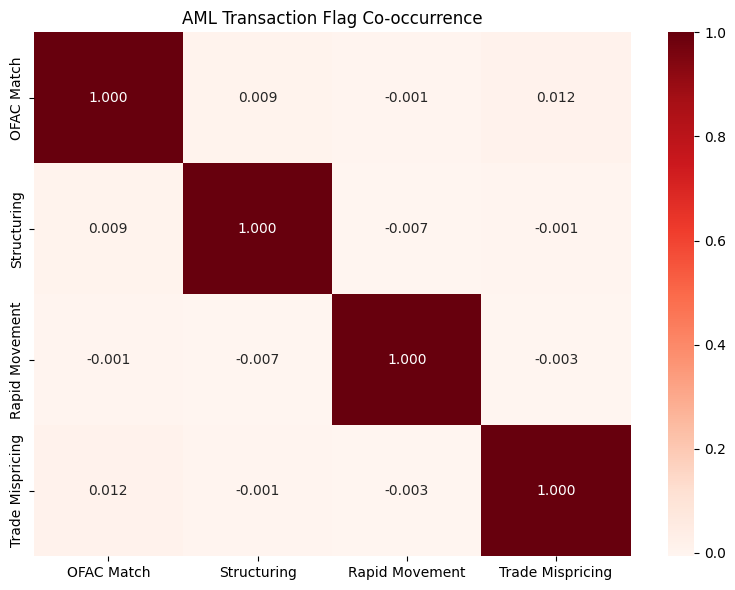

In [11]:
# ── Plot 7: AML Transaction Flag Co-occurrence ────────────────────
aml_flags = kyc1[['ofac_match_flag','structuring_pattern_flag','rapid_movement_flag','trade_mispricing_flag']]
corr = aml_flags.corr()
fig7, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Reds', fmt='.3f', ax=ax,
            xticklabels=['OFAC Match','Structuring','Rapid Movement','Trade Mispricing'],
            yticklabels=['OFAC Match','Structuring','Rapid Movement','Trade Mispricing'])
ax.set_title('AML Transaction Flag Co-occurrence')
plt.tight_layout()
plt.show()

In [12]:
# ── Plot 8: AML Flags by Transaction Type ─────────────────────────
fig8 = go.Figure()
for col, name, color in [('ofac_hits','OFAC Hits','#C0001A'),
                          ('structuring','Structuring','#F39C12'),
                          ('rapid_movement','Rapid Movement','#006FCF')]:
    fig8.add_trace(go.Bar(name=name, x=q7['transaction_type'], y=q7[col],
                          marker_color=color))
fig8.update_layout(barmode='group', title='AML Flags by Transaction Type',
                   template='plotly_white', height=450,
                   yaxis_title='Flag Count', xaxis_title='Transaction Type')
fig8.show()

In [13]:
# ── Save cleaned data ───────────────────────────────────────────────
kyc_merged.to_csv('../../data/processed/kyc_clean.csv', index=False)
print(f"Saved kyc_clean.csv — shape {kyc_merged.shape}")

con.close()

Saved kyc_clean.csv — shape (2000, 24)
